In [2]:
import numpy as np
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp
import sys
from pathlib import Path
import importlib
# add Modeling/ to Python path
project_root = Path.cwd().parents[2]
sys.path.append(str(project_root))
from Modeling.models.plotting import animate_field_1d
from Modeling.models.beam_properties import PiezoBeamParams

import matplotlib.pyplot as plt
# from Modeling.models.ROM import ROM

import Modeling.models.FE1 as FE1_module
importlib.reload(FE1_module)
FE1 = FE1_module
import Modeling.models.ROM as ROM_module
importlib.reload(ROM_module)
ROM = ROM_module.ROM

# from FE1 import PiezoBeamFE, frf_sweep, solve_newmark
import numpy as np
from numpy import pi	
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from IPython.display import clear_output
from matplotlib import cm, colors
import pandas as pd
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

X shape: (901,) Y shape: (901, 125) freq shape: (901,) veloc shape: (901, 125)


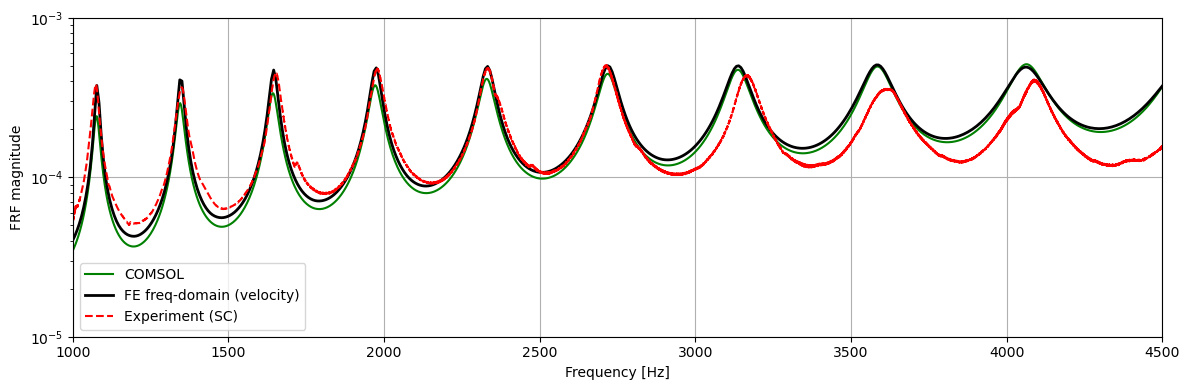

In [3]:

K_i = 0; K_p = 200; K_c = 0; R_c = 1e3
t_end = 0.01
f0 = 1000
f1 = 4500
dt = 1/f1/20
def v_exc(t, A_exc=50, f0=f0, f1=f1, t_end=t_end):
	return A_exc*np.sin(2*np.pi*(f0+ t*(f1-f0)/t_end) *t)
# N = 40
# hp, hs = 0.31e-3, 0.607e-3 		
params_fe = PiezoBeamParams(hp=0.252e-3, hs=0.51e-3)
params_fe.zeta_p = 0.0151*8
params_fe.zeta_q = 0.0392*10

fe = FE1.PiezoBeamFE(params_fe, n_el_gap=1,n_el_patch=3)
ode = fe.build_ode_system(
    j_exc=30,
    K_c=K_c,    # linear circuit
    K_i=K_i,
    K_p= K_p,
	v_exc=v_exc
)
f_fe = np.linspace(f0, f1, 500)
frf_fd = FE1.frf_sweep(ode, f_fe*2*pi)
N = ode.N_mech
w_fd = frf_fd['u']
w_dot_fd = frf_fd['u_dot']


# time grid and ICs
t_eval = np.arange(0, t_end, dt)
ndof = ode.M.shape[0]

x0 = np.zeros(ndof)
x_dot0 = np.zeros(ndof)

result = FE1.solve_newmark(
	ode=ode,
	dt=dt,
	t_end=t_end,
	beta=0.25,
	gamma=0.5,
	newton_tol=1e-8,
	newton_maxiter=8,
	x0=x0,
	x_dot0=x_dot0
	)

# Extract results from dictionary
t = result['t']
w = result['u']                # mechanical displacement
w_dot = result['u_dot']        # mechanical velocity
w_ddot = result['u_ddot']      # mechanical acceleration
q = result['q']                # electrical charge
v = result['v']                # voltage
spec_td = result['spectral']   # time-domain FRF dictionary (freq, FRF)
# Frequency-domain vs time-domain FRF overlay with experimental/COMSOL
try:
    # Load experimental datasets (same as FE_OC)
    npz_path_OC = r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\11\OC.npz".replace("\\", "/")
    npz_path_SC = r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\7\kc0_kp_sweep\OCSC\SC.npz".replace("\\", "/")
    npz_path_OC = r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\7\kc0_kp_sweep\OCSC\OC.npz".replace("\\", "/")
    npz_path_linear = r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\11\linear_lowdamping.npz".replace("\\", "/")
    data_OC = np.load(npz_path_OC)
    data_SC = np.load(npz_path_SC)
    data_linear = np.load(npz_path_linear)
    frq_OC_exp = data_OC['freq']
    frf_OC_exp = data_OC['frf_data']  # (Nfiles, Nfreq, Npoints)
    frq_SC_exp = data_SC['freq']
    frf_SC_exp = data_SC['frf_data']
    frq_linear_exp = data_linear['freq']
    frf_linear_exp = data_linear['frf_data']
except Exception as e:
    print("Experimental data not loaded:", e)
    frq_OC_exp = frf_OC_exp = frq_SC_exp = frf_SC_exp = frq_linear_exp = frf_linear_exp = None

# COMSOL reference
try:
    comsol = pd.read_csv('../../../comsol/LR.csv')
    comsol = pd.read_csv('../../../comsol/SC.csv')
except Exception as e:
    print("COMSOL data not loaded:", e)
    comsol = None

# Frequency-domain FE FRF (velocity magnitude averaged over transverse DOFs)
freq_fd = frf_fd['freq']
vel_fd = np.mean(np.abs(w_dot_fd), axis=1)

# Time-domain FRF from transient (if available)
if spec_td is not None and spec_td['freq'] is not None:
    freq_td = spec_td['freq']
    frf_td = spec_td['FRF']
else:
    freq_td = None
    frf_td = None

plt.figure(figsize=(12, 4))

plt.semilogy(comsol['freq'], comsol['w']*2*np.pi*comsol['freq'], 'g-', label='COMSOL')
# plt.semilogy(frq_linear_exp, np.mean(frf_linear_exp, axis=1), 'k--', label='Experiment (linear)')
plt.semilogy(freq_fd, vel_fd/1.6,'k-' , lw=2, label='FE freq-domain (velocity)')
# plt.semilogy(frq_OC_exp, np.mean(frf_OC_exp, axis=1), 'r--', label='Experiment (OC)')
plt.semilogy(frq_SC_exp, np.mean(frf_SC_exp, axis=1), 'r--', label='Experiment (SC)')
# plt.semilogy(freq_td, frf_td/1.5, '.-', label='FE time-domain (velocity)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('FRF magnitude')
plt.xlim([1000, 4500])
plt.ylim([1e-5, 1e-3])
plt.grid(True)
plt.legend()
# plt.title('FRF overlay: experimental, COMSOL, FE (freq), FE (time)')
plt.tight_layout()
plt.show()


In [10]:
K_i = 2000; K_p = 0.03; K_c =2.5e10 ; R_c = 1e3
t_end = 1.0
f0 = 1000
f1 = 3000
dt = 1/f1/50
from joblib import Parallel, delayed
# Create excitation function factory
def make_v_exc(A):
	def v_exc(t_var, A_exc=A, f0=f0, f1=f1, t_end=t_end):
		return A_exc * np.sin(2*np.pi*(f0 + t_var*(f1-f0)/t_end) * t_var)
	return v_exc

# Function to run single amplitude simulation
def run_amplitude_case(A, fe, params, K_c, K_i, K_p, dt, t_end):
	"""Run one simulation for given excitation amplitude A."""
	print(f"  Amplitude = {A}")
	
	v_exc = make_v_exc(A)
	
	ode = fe.build_ode_system(
		j_exc=30,
		K_c=K_c,  # example nonlinear circuit
		K_i=K_i,
		K_p=K_p,
		R_c=R_c,
		v_exc=v_exc
	)
	
	result = FE1.solve_newmark(
		ode=ode,
		dt=dt,
		t_end=t_end,
		beta=0.25,
		gamma=0.5,
		newton_tol=1e-8,
		newton_maxiter=8,
		x0=np.zeros(ode.M.shape[0]),
		x_dot0=np.zeros(ode.M.shape[0]),
		do_spectral=True
	)
	
	return {
		"A": A,
		"freq": result['spectral']['freq'],
		"FRF": result['spectral']['FRF']
	}

# Amplitude sweep parameters
A_list = np.linspace(5, 50, 8)  # excitation amplitudes
print(f"Running amplitude sweep for A = {A_list}...")

# Run in parallel
sweep_results = Parallel(n_jobs=4, verbose=10)(
	delayed(run_amplitude_case)(A, fe, params_fe, K_c, K_i, K_p, dt, t_end)
	for A in A_list
)

print("Amplitude sweep completed!")


Running amplitude sweep for A = [ 5.         11.42857143 17.85714286 24.28571429 30.71428571 37.14285714
 43.57142857 50.        ]...


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   2 out of   8 | elapsed:  2.7min remaining:  8.2min
[Parallel(n_jobs=4)]: Done   3 out of   8 | elapsed:  3.1min remaining:  5.2min
[Parallel(n_jobs=4)]: Done   4 out of   8 | elapsed:  3.5min remaining:  3.5min
[Parallel(n_jobs=4)]: Done   5 out of   8 | elapsed:  5.4min remaining:  3.2min
[Parallel(n_jobs=4)]: Done   6 out of   8 | elapsed:  5.5min remaining:  1.8min


Amplitude sweep completed!


[Parallel(n_jobs=4)]: Done   8 out of   8 | elapsed:  6.8min finished


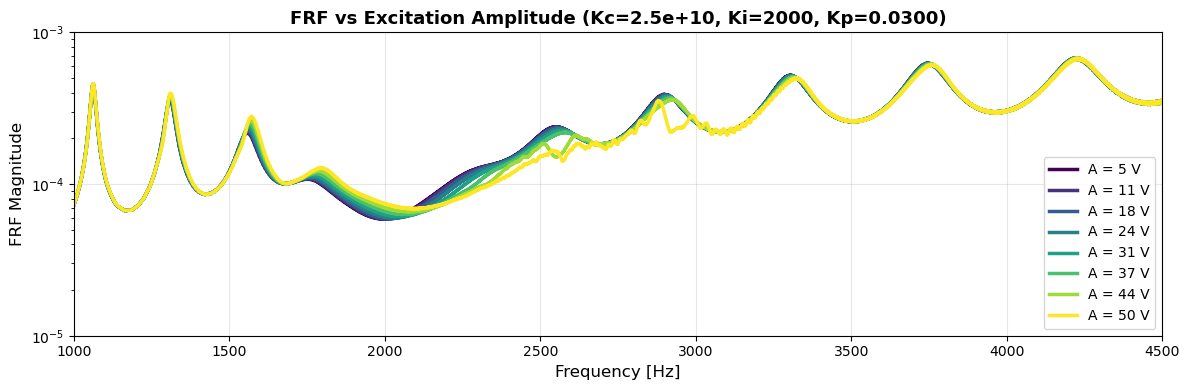

In [11]:

# Plot FRF overlay with color gradient
plt.figure(figsize=(12, 4))
cmap = plt.cm.viridis
colors_amp = cmap(np.linspace(0, 1, len(A_list)))

for i, result in enumerate(sweep_results):
	A = result['A']
	freq = result['freq']
	frf = result['FRF']
	plt.semilogy(freq, frf, '-', linewidth=2.5, 
				label=f'A = {A:0.0f} V', color=colors_amp[i])

plt.xlabel('Frequency [Hz]', fontsize=12)
plt.ylabel('FRF Magnitude', fontsize=12)
plt.xlim([1000, 4500])
plt.ylim([1e-5, 1e-3])
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, loc='best')
plt.title(f'FRF vs Excitation Amplitude (Kc={K_c:.1e}, Ki={K_i:.0f}, Kp={K_p:.4f})', 
		fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [6]:
w.shape
print("w:", w.shape,  "t:", t.shape, "q:", q.shape, "u_dot:", w_dot.shape, "u_ddot:", w_ddot.shape)


w: (901, 125) t: (901,) q: (901, 30) u_dot: (901, 125) u_ddot: (901, 125)


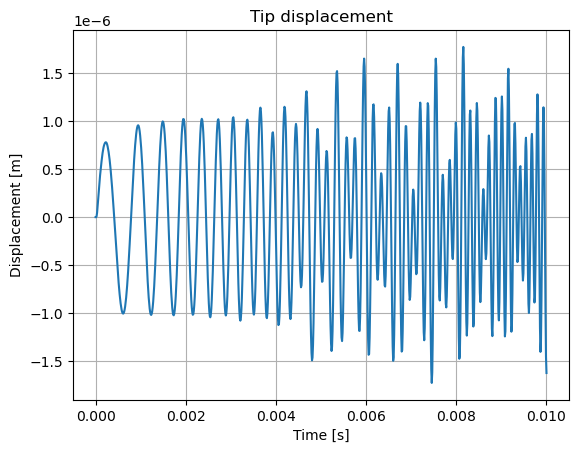

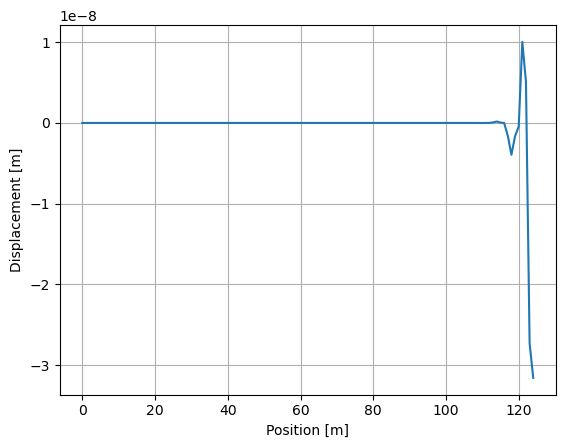

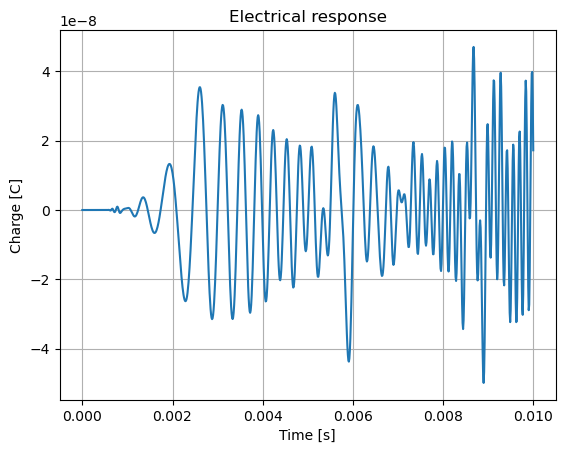

In [7]:


plt.figure()
plt.plot(t, w[:, 120])
plt.xlabel("Time [s]")
plt.ylabel("Displacement [m]")
plt.title("Tip displacement")
plt.grid(True)
plt.show()


plt.figure()
plt.plot( w[1, :])
plt.xlabel("Position [m]")
plt.ylabel("Displacement [m]")
plt.title("")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(t, q[:, 0])
plt.xlabel("Time [s]")
plt.ylabel("Charge [C]")
plt.title("Electrical response")
plt.grid(True)
plt.show()


Saved animation to beam_displacement2.gif


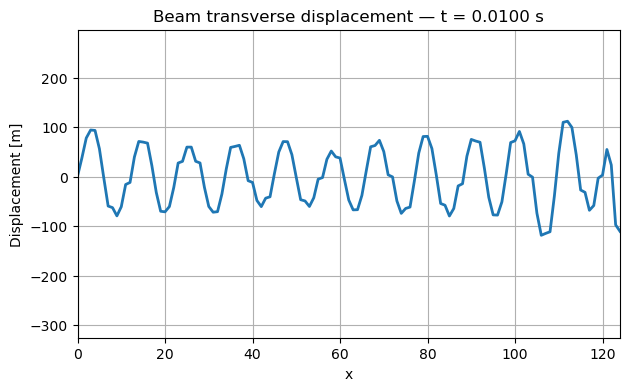

In [8]:

animate_field_1d(
	t=t,
	u=w_dot,
	# x=fe.x_nodes_free,
	filename="beam_displacement2.gif",
	scale=2000,
    stride=2,
	ylabel="Displacement [m]",
	title="Beam transverse displacement"
)
